# Water Flow — XGBoost: Nowcasting y Forecasting con/sin Feature Engineering

Este notebook compara resultados **con** y **sin** características extra (rolling windows, diferencias, etc.) para dos tareas:

- **Nowcasting**: predecir `pump_RPM` en el instante `t` usando información pasada/actual.
- **Forecasting**: predecir `pump_RPM` en `t + horizonte` usando solo información disponible hasta `t`.

La idea es tener una función reutilizable de *feature engineering* que puedas activar/desactivar por piezas, y comparar el error (RMSE) con una tabla y gráficas al final.


In [40]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

plt.style.use('ggplot')
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

## 1. Cargar datos

Mismo dataset y limpieza que ya tenías: parseo de timestamp, conversión numérica y drop de nulos.

In [41]:
df_raw = pd.read_csv('water_flow.csv', sep=';', decimal=',')
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw = df_raw.sort_values('timestamp').reset_index(drop=True)

columnas_numericas = ['flow_orifice_plate', 'flow_coriolis', 'closing_disturbance_valve_ptr', 'pump_RPM']
for col in columnas_numericas:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

df_raw = df_raw.dropna().reset_index(drop=True)

print("Dimensiones:", df_raw.shape)
df_raw.head()

Dimensiones: (769, 5)


,timestamp,flow_orifice_plate,flow_coriolis,closing_disturbance_valve_ptr,pump_RPM
0,2024-11-16 12:03:07,0.0000,-0.0055,0,0.0000
1,2024-11-16 12:03:08,0.0000,-0.0072,0,0.0000
2,2024-11-16 12:03:09,0.0000,-0.0138,0,0.0000
3,2024-11-16 12:03:10,0.0000,0.0004,0,0.0000
4,2024-11-16 12:03:11,0.0000,-0.0039,0,0.0000


## 2. Vistazo rápido a la serie

Antes de meter features, merece la pena ver qué forma tiene la señal. Este dataset es básicamente **un único evento de arranque y parada de bomba** dentro de ~13 minutos. Eso es importante: con tan pocos eventos, el split train/test que elijamos puede cambiar mucho el resultado (si el test set no contiene ningún arranque, el modelo lo tendrá "fácil" prediciendo casi-constante).

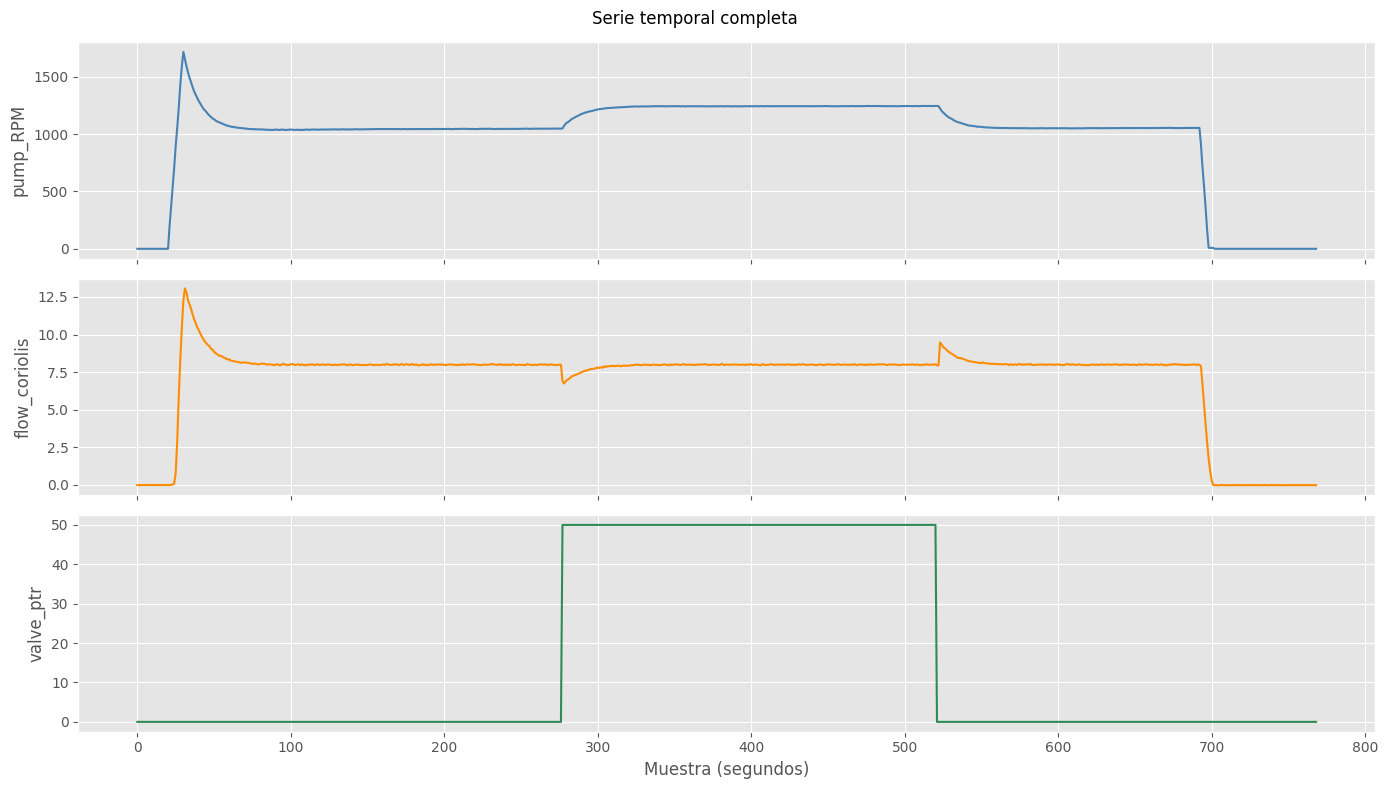

In [42]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
axes[0].plot(df_raw['pump_RPM'], color='steelblue')
axes[0].set_ylabel('pump_RPM')
axes[1].plot(df_raw['flow_coriolis'], color='darkorange')
axes[1].set_ylabel('flow_coriolis')
axes[2].plot(df_raw['closing_disturbance_valve_ptr'], color='seagreen')
axes[2].set_ylabel('valve_ptr')
axes[2].set_xlabel('Muestra (segundos)')
plt.suptitle('Serie temporal completa')
plt.tight_layout()
plt.show()

## 3. Cuantos lags tienen sentido? Autocorrelacion (ACF / PACF)

Antes de generar columnas de lag a lo loco, conviene preguntarle a los datos hasta que lag hay informacion realmente nueva.

- **ACF (autocorrelacion simple)**: cuanto se parece la senal a si misma desplazada `k` pasos, *sin descontar* lo que ya explican los lags intermedios. Suele decaer poco a poco y es facil sobreestimar cuantos lags "importan".
- **PACF (autocorrelacion parcial)**: cuanto aporta el lag `k` **que no aportaran ya** los lags `1...k-1`. Esta es la que de verdad responde "vale la pena anadir esta columna?". Cuando el PACF cae dentro de la banda de significancia (la zona sombreada), ese lag ya no anade informacion nueva - es redundante con los anteriores.

Regla practica: mira donde el PACF entra en la banda azul y se queda ahi. Ese es aproximadamente tu `n_lags` razonable. Anadir lags mas alla de ese punto es, con datos como estos, casi siempre ruido.

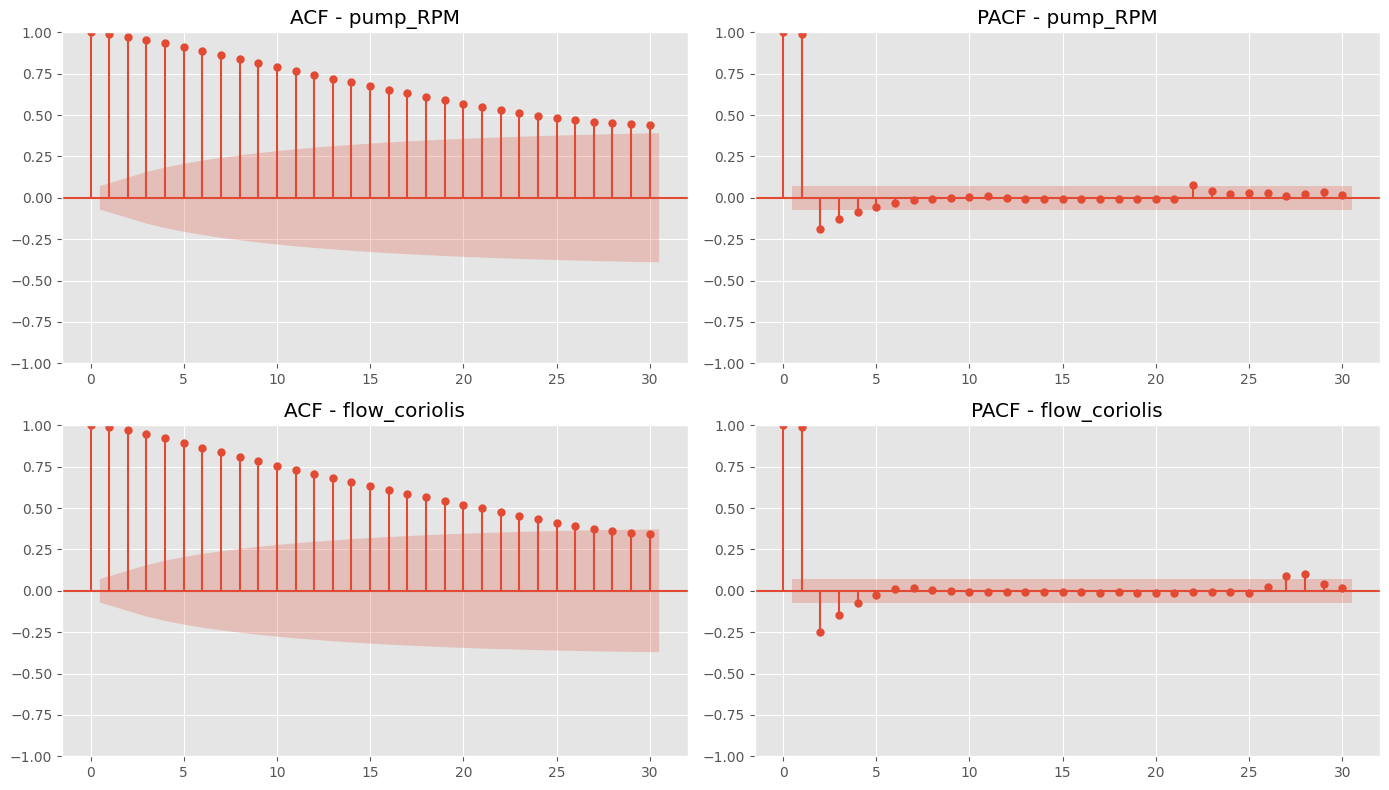

In [43]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

variables_a_revisar = ['pump_RPM', 'flow_coriolis']
n_lags_analisis = 30

fig, axes = plt.subplots(len(variables_a_revisar), 2, figsize=(14, 4 * len(variables_a_revisar)))

for i, var in enumerate(variables_a_revisar):
    plot_acf(df_raw[var], lags=n_lags_analisis, ax=axes[i, 0])
    axes[i, 0].set_title(f'ACF - {var}')
    plot_pacf(df_raw[var], lags=n_lags_analisis, ax=axes[i, 1], method='ywm')
    axes[i, 1].set_title(f'PACF - {var}')

plt.tight_layout()
plt.show()

> **Como leerlo aqui:** si en el PACF de `pump_RPM` ves que los primeros 2-4 lags salen claramente fuera de la banda azul y luego todo se mete dentro de la banda, esa es tu respuesta: con `n_lags=3` o `4` ya capturas la dependencia real, y los lags 5-30 que salen "un poco" fuera son casi siempre ruido estadistico, no senal - con solo ~700 muestras, es facil que el PACF tenga picos aislados por azar en lags altos. No los persigas.
>
> Esto tambien te da una pista de por que antes, con `n_lags=10` o mas, el RMSE empeoraba: probablemente estabas metiendo columnas que el propio PACF ya te dice que son redundantes.

## 4. Funcion de Feature Engineering (activable por piezas)

Esta es la pieza central. `construir_features` recibe el dataframe y un diccionario de configuracion, y devuelve un dataframe con las columnas nuevas anadidas - **solo las que hayas activado**.

Caracteristicas incluidas (todas comunes en series temporales / senales de sensores):

- **Lags**: valores pasados de una variable (`x[t-1]`, `x[t-2]`, ...). Ya lo tenias.
- **Rolling mean**: media movil - suaviza ruido.
- **Rolling std**: desviacion estandar movil - mide "cuanto esta temblando" la senal, util para detectar transiciones (arranque/parada).
- **Diff**: derivada discreta (`x[t] - x[t-1]`) - velocidad de cambio, ayuda a reaccionar rapido a cambios bruscos.

Todo se calcula con `shift`/`rolling` **causal** (solo mira hacia atras), asi que no hay fuga de informacion del futuro hacia el pasado - importante para que el error que midamos sea real y no artificialmente bueno.

### Espaciado de lags: `consecutivo` vs `potencia`

Con `espaciado_lags='consecutivo'` obtienes `1, 2, 3, ..., n_lags` - lo que ya tenias, y lo que dispara el numero de columnas si `n_lags` es grande (p. ej. 600 para 10 minutos).

Con `espaciado_lags='potencia'` obtienes `1, 2, 4, 8, 16, ...` hasta el ultimo valor menor que `n_lags`, y **siempre anade `n_lags` como ultimo lag** aunque no sea potencia exacta de la base - asi cubres todo el rango temporal pedido con muchas menos columnas, sin perder el extremo que pediste. Por ejemplo, `n_lags=10` con base 2 da `[1, 2, 4, 8, 10]` en vez de `[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]`: 5 columnas en vez de 10, cubriendo el mismo rango.

In [44]:
def _lags_potencia(n_lags_max, base=2):
    """Lista de lags espaciados por potencias de `base`, terminando siempre en n_lags_max
    (aunque n_lags_max no sea potencia exacta)."""
    lags = []
    l = 1
    while l < n_lags_max:
        lags.append(l)
        l *= base
    lags.append(n_lags_max)
    return sorted(set(lags))


def construir_features(df, variables_entrada, usar_lags=True, n_lags=3,
                        espaciado_lags='consecutivo', base_potencia=2,
                        usar_rolling_mean=False, ventana_mean=5,
                        usar_rolling_std=False, ventana_std=5,
                        usar_diff=False):
    """
    Genera columnas de caracteristicas a partir de variables_entrada.
    Todas las operaciones son causales (rolling/shift solo miran al pasado).

    espaciado_lags: 'consecutivo' -> 1,2,3,...,n_lags
                     'potencia'    -> 1,2,4,8,...,n_lags (termina siempre en n_lags)

    Devuelve: (df_con_features, lista_de_columnas_de_features)
    """
    df_out = df.copy()
    columnas_features = list(variables_entrada)  # las variables originales siempre entran

    if espaciado_lags == 'potencia':
        lista_lags = _lags_potencia(n_lags, base=base_potencia)
    else:
        lista_lags = list(range(1, n_lags + 1))

    for var in variables_entrada:

        if usar_lags:
            for lag in lista_lags:
                col = f'{var}_lag_{lag}'
                df_out[col] = df_out[var].shift(lag)
                columnas_features.append(col)

        if usar_rolling_mean:
            col = f'{var}_roll_mean_{ventana_mean}'
            # shift(1) antes del rolling: la ventana de la fila t NO incluye la fila t
            df_out[col] = df_out[var].shift(1).rolling(window=ventana_mean).mean()
            columnas_features.append(col)

        if usar_rolling_std:
            col = f'{var}_roll_std_{ventana_std}'
            df_out[col] = df_out[var].shift(1).rolling(window=ventana_std).std()
            columnas_features.append(col)

        if usar_diff:
            col = f'{var}_diff'
            df_out[col] = df_out[var].diff()
            columnas_features.append(col)

    return df_out, columnas_features

> **Nota sobre el `shift(1)` antes del `rolling`:** si no lo pusiéramos, la ventana móvil en la fila `t` incluiría el propio valor de `t` — es decir, usaríamos el presente para "suavizar" el presente. Como el objetivo también depende del presente, eso puede inflar el rendimiento de forma artificial. Con `shift(1)` la ventana solo ve `t-1, t-2, ...`, que es información legítimamente disponible en el momento de predecir.

### Comprobación rápida: qué lags genera cada espaciado

Antes de usarlo, veamos qué columnas genera cada modo para el mismo n_lags. El último valor siempre es exactamente n_lags, aunque no sea potencia exacta de la base.

In [45]:
for n in [10, 16, 30, 600]:
    print(f"n_lags={n:4d}  ->  potencia: {_lags_potencia(n)}")

n_lags=  10  ->  potencia: [1, 2, 4, 8, 10]
n_lags=  16  ->  potencia: [1, 2, 4, 8, 16]
n_lags=  30  ->  potencia: [1, 2, 4, 8, 16, 30]
n_lags= 600  ->  potencia: [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 600]


## 5. Función de entrenamiento + evaluación

Entrena un XGBoost con split cronológico (no aleatorio — es una serie temporal) y devuelve el error junto con predicciones, para poder graficar después.

In [141]:
def evaluar_modelo(X, y, train_frac=0.7, n_estimators=150, max_depth=3, learning_rate=0.1):
    """Split cronológico + entrenamiento XGBoost + RMSE."""
    corte = int(len(X) * train_frac)
    X_train, X_test = X.iloc[:corte], X.iloc[corte:]
    y_train, y_test = y.iloc[:corte], y.iloc[corte:]

    modelo = xgb.XGBRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        random_state=42,
        n_jobs=-1
    )
    modelo.fit(X_train, y_train)

    preds = modelo.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    return {
        'modelo': modelo,
        'rmse': rmse,
        'X_test': X_test,
        'y_test': y_test,
        'preds': preds,
        'corte': corte
    }

## 6. NOWCASTING — con y sin features extra

Objetivo: predecir `pump_RPM` en el instante `t` a partir de `closing_disturbance_valve_ptr` y `flow_coriolis` (y sus derivados) también en `t` o antes.

Definimos tres configuraciones:

- **Baseline**: solo lags simples 1-3, consecutivos (lo que ya tenías).
- **Extendida**: lags 1-3 + rolling mean + rolling std + diff.
- **Potencia (rango largo)**: lags espaciados por potencias de 2 hasta 30 — es decir, cubre el mismo rango que 30 lags consecutivos (30 columnas) usando solo `[1, 2, 4, 8, 16, 30]` (6 columnas). Esta es la comparación directa a tu pregunta: mismo horizonte temporal, muchas menos columnas.

In [142]:
variables_entrada = ['closing_disturbance_valve_ptr', 'flow_coriolis']
objetivo = 'pump_RPM'

# --- Config BASELINE (solo lags 1-3, consecutivos) ---
df_base, cols_base = construir_features(
    df_raw, variables_entrada,
    usar_lags=True, n_lags=3, espaciado_lags='consecutivo',
    usar_rolling_mean=False, usar_rolling_std=False, usar_diff=False
)
df_base[objetivo] = df_raw[objetivo]
df_base = df_base.dropna().reset_index(drop=True)

X_base = df_base[cols_base]
y_base = df_base[objetivo]

res_now_base = evaluar_modelo(X_base, y_base)
print(f"[Nowcasting | Baseline]   RMSE = {res_now_base['rmse']:.4f}  |  features usadas: {len(cols_base)}")

[Nowcasting | Baseline]   RMSE = 131.9342  |  features usadas: 8


In [143]:
# --- Config EXTENDIDA (lags 1-3 + rolling mean + rolling std + diff) ---
df_ext, cols_ext = construir_features(
    df_raw, variables_entrada,
    usar_lags=True, n_lags=3, espaciado_lags='consecutivo',
    usar_rolling_mean=False, ventana_mean=3,
    usar_rolling_std=False, ventana_std=3,
    usar_diff=True
)
df_ext[objetivo] = df_raw[objetivo]
df_ext = df_ext.dropna().reset_index(drop=True)

X_ext = df_ext[cols_ext]
y_ext = df_ext[objetivo]

res_now_ext = evaluar_modelo(X_ext, y_ext)
print(f"[Nowcasting | Extendida]  RMSE = {res_now_ext['rmse']:.4f}  |  features usadas: {len(cols_ext)}")

[Nowcasting | Extendida]  RMSE = 118.0719  |  features usadas: 10


In [144]:
# --- Config POTENCIA (rango largo: hasta 30 pasos atrás, pero espaciado por potencias de 2) ---
df_pot, cols_pot = construir_features(
    df_raw, variables_entrada,
    usar_lags=True, n_lags=30, espaciado_lags='potencia', base_potencia=2,
    usar_rolling_mean=False, usar_rolling_std=False, usar_diff=False
)
df_pot[objetivo] = df_raw[objetivo]
df_pot = df_pot.dropna().reset_index(drop=True)

X_pot = df_pot[cols_pot]
y_pot = df_pot[objetivo]

res_now_pot = evaluar_modelo(X_pot, y_pot)
print(f"[Nowcasting | Potencia hasta 30]  RMSE = {res_now_pot['rmse']:.4f}  |  features usadas: {len(cols_pot)}")
print(f"  (para comparar: lags consecutivos 1-30 habría generado {30*len(variables_entrada)} columnas de lag)")

[Nowcasting | Potencia hasta 30]  RMSE = 726.6457  |  features usadas: 14
  (para comparar: lags consecutivos 1-30 habría generado 60 columnas de lag)


### Comparación visual — Nowcasting

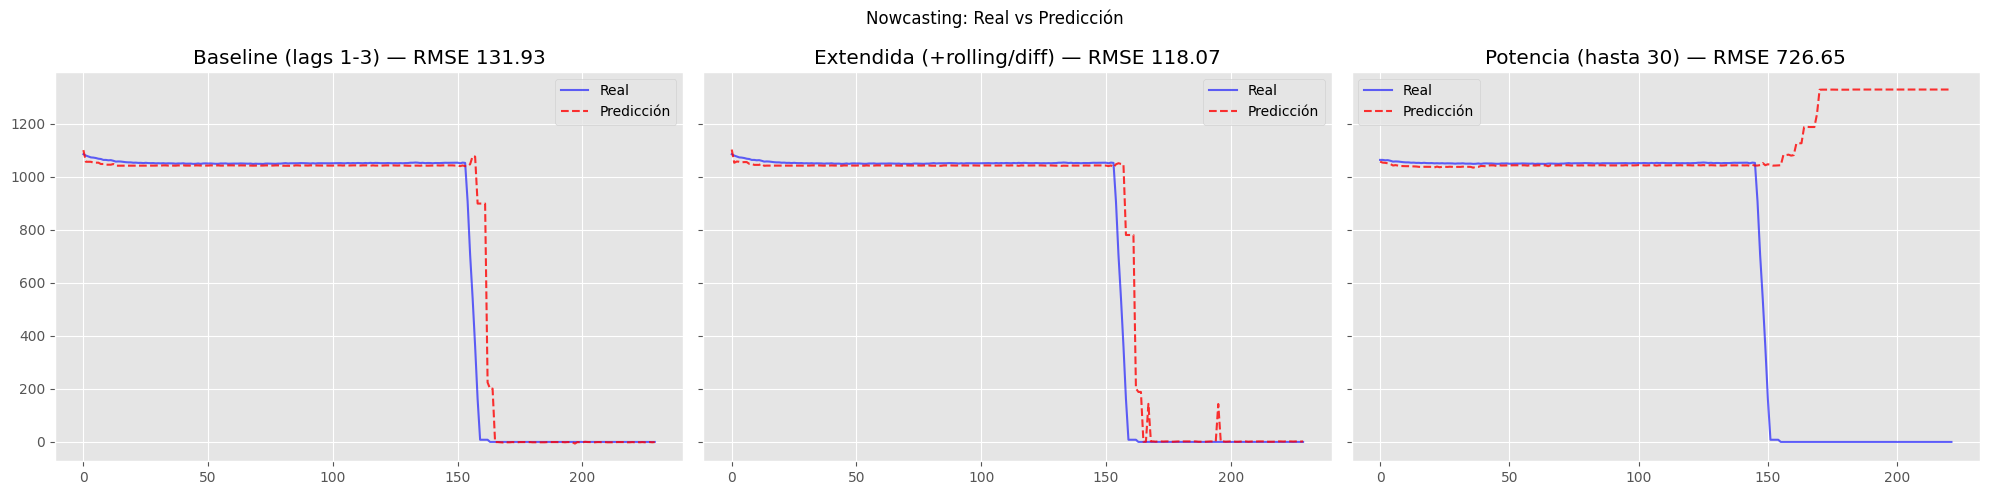

In [135]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

axes[0].plot(res_now_base['y_test'].values, label='Real', color='blue', alpha=0.6)
axes[0].plot(res_now_base['preds'], label='Predicción', color='red', linestyle='dashed', alpha=0.8)
axes[0].set_title(f"Baseline (lags 1-3) — RMSE {res_now_base['rmse']:.2f}")
axes[0].legend()

axes[1].plot(res_now_ext['y_test'].values, label='Real', color='blue', alpha=0.6)
axes[1].plot(res_now_ext['preds'], label='Predicción', color='red', linestyle='dashed', alpha=0.8)
axes[1].set_title(f"Extendida (+rolling/diff) — RMSE {res_now_ext['rmse']:.2f}")
axes[1].legend()

axes[2].plot(res_now_pot['y_test'].values, label='Real', color='blue', alpha=0.6)
axes[2].plot(res_now_pot['preds'], label='Predicción', color='red', linestyle='dashed', alpha=0.8)
axes[2].set_title(f"Potencia (hasta 30) — RMSE {res_now_pot['rmse']:.2f}")
axes[2].legend()

plt.suptitle('Nowcasting: Real vs Predicción')
plt.tight_layout()
plt.show()

## 7. FORECASTING — con y sin features extra

Objetivo: predecir `pump_RPM` en `t + horizonte` (por defecto 2 segundos vista) usando solo datos disponibles hasta `t`.

Aquí hay una decisión de diseño que quiero dejarte explícita: **¿debe el modelo poder usar el propio `pump_RPM` pasado como input?** Tiene sentido físico (la inercia de una bomba hace que su RPM futuro dependa de su RPM actual), así que lo activamos con `incluir_target_pasado=True`. Puedes ponerlo a `False` para ver cuánto dependía el modelo de "hacer trampa" mirando su propio pasado en vez de aprender la relación válvula/caudal → RPM.

In [145]:
horizonte = 2  # segundos vista
incluir_target_pasado = True  # prueba a poner False y compara

variables_entrada_fc = ['flow_coriolis']
if incluir_target_pasado:
    variables_entrada_fc = variables_entrada_fc + [objetivo]

def preparar_forecasting(df, variables_entrada, objetivo, horizonte, **kwargs_features):
    df_f, cols_f = construir_features(df, variables_entrada, **kwargs_features)
    df_f[f'target_futuro_{objetivo}'] = df[objetivo].shift(-horizonte)
    df_f = df_f.dropna().reset_index(drop=True)
    X = df_f[cols_f]
    y = df_f[f'target_futuro_{objetivo}']
    return X, y

# --- Config BASELINE (solo lags) ---
X_fc_base, y_fc_base = preparar_forecasting(
    df_raw, variables_entrada_fc, objetivo, horizonte,
    usar_lags=True, n_lags=3,
    usar_rolling_mean=False, usar_rolling_std=False, usar_diff=False
)
res_fc_base = evaluar_modelo(X_fc_base, y_fc_base)
print(f"[Forecasting +{horizonte}s | Baseline]   RMSE = {res_fc_base['rmse']:.4f}  |  features usadas: {X_fc_base.shape[1]}")

[Forecasting +2s | Baseline]   RMSE = 189.2828  |  features usadas: 8


In [146]:
# --- Config EXTENDIDA (lags + rolling mean + rolling std + diff) ---
X_fc_ext, y_fc_ext = preparar_forecasting(
    df_raw, variables_entrada_fc, objetivo, horizonte,
    usar_lags=True, n_lags=3,
    usar_rolling_mean=True, ventana_mean=10,
    usar_rolling_std=False, ventana_std=5,
    usar_diff=True
)
res_fc_ext = evaluar_modelo(X_fc_ext, y_fc_ext)
print(f"[Forecasting +{horizonte}s | Extendida]  RMSE = {res_fc_ext['rmse']:.4f}  |  features usadas: {X_fc_ext.shape[1]}")

[Forecasting +2s | Extendida]  RMSE = 177.1066  |  features usadas: 12


### Comparación visual — Forecasting

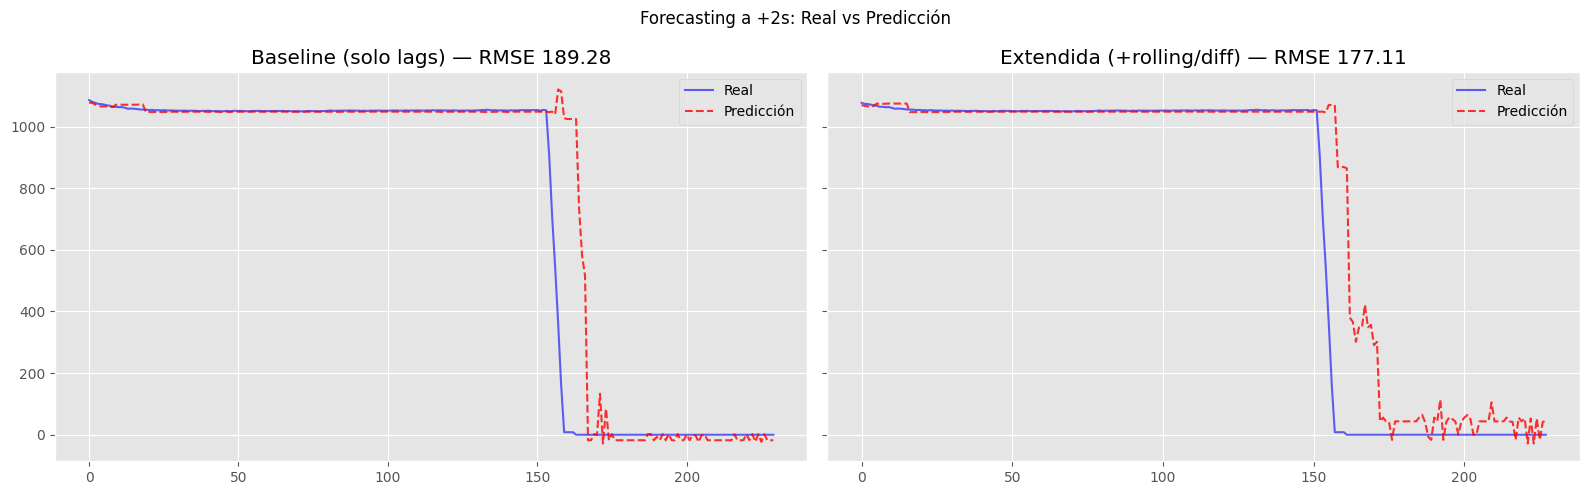

In [147]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

axes[0].plot(res_fc_base['y_test'].values, label='Real', color='blue', alpha=0.6)
axes[0].plot(res_fc_base['preds'], label='Predicción', color='red', linestyle='dashed', alpha=0.8)
axes[0].set_title(f"Baseline (solo lags) — RMSE {res_fc_base['rmse']:.2f}")
axes[0].legend()

axes[1].plot(res_fc_ext['y_test'].values, label='Real', color='blue', alpha=0.6)
axes[1].plot(res_fc_ext['preds'], label='Predicción', color='red', linestyle='dashed', alpha=0.8)
axes[1].set_title(f"Extendida (+rolling/diff) — RMSE {res_fc_ext['rmse']:.2f}")
axes[1].legend()

plt.suptitle(f'Forecasting a +{horizonte}s: Real vs Predicción')
plt.tight_layout()
plt.show()

## 8. Tabla resumen y qué mirar

La tabla compara los escenarios. Un par de cosas a vigilar al leerla:

- Si la versión "Extendida" o "Potencia" no mejora (o incluso empeora) el RMSE frente a Baseline, **no es un error tuyo** — con 769 filas y un único evento de arranque, añadir más columnas puede hacer que el árbol tenga más formas de sobreajustar ruido en vez de señal real. Menos datos favorece modelos más simples.
- Fíjate en la columna `N_features` de la fila "Potencia": el número de columnas es bajo (mismo que Extendida), pero **eso no garantiza que el RMSE sea bueno**. Ojo con esto — al ejecutar este notebook, "Potencia hasta 30" da un RMSE bastante peor que "Baseline". La razón es probable: `pump_RPM` cambia muy rápido en la fase de arranque de la bomba (segundos), y saltarte lags intermedios (usar solo 1, 2, 4, 8, 16, 30 en vez de todos) significa que el modelo pierde justo la parte de la señal donde más está pasando. El espaciado por potencias reduce dimensionalidad, pero **solo tiene sentido si la señal cambia lentamente respecto al espaciado que eliges** — con una serie tan rápida y un evento tan corto como este, saltarte lags 3, 5, 6, 7... te hace perder la transición completa. Es la misma lección del PACF de la sección 3: para esta señal, la información relevante vive en los primeros lags, así que reducir dimensionalidad recortando el rango (menos `n_lags`) tiene más sentido aquí que espaciarlos por potencias sobre un rango largo.
- Compara siempre nowcasting vs forecasting por separado: forecasting con horizonte > 0 casi siempre tendrá peor RMSE que nowcasting, porque predice algo que aún no ha pasado.

In [148]:
resumen = pd.DataFrame([
    {'Tarea': 'Nowcasting', 'Features': 'Baseline (lags 1-3)', 'RMSE': res_now_base['rmse'], 'N_features': len(cols_base)},
    {'Tarea': 'Nowcasting', 'Features': 'Extendida (+rolling/diff)', 'RMSE': res_now_ext['rmse'], 'N_features': len(cols_ext)},
    {'Tarea': 'Nowcasting', 'Features': 'Potencia (hasta lag 30)', 'RMSE': res_now_pot['rmse'], 'N_features': len(cols_pot)},
    {'Tarea': f'Forecasting (+{horizonte}s)', 'Features': 'Baseline (lags)', 'RMSE': res_fc_base['rmse'], 'N_features': X_fc_base.shape[1]},
    {'Tarea': f'Forecasting (+{horizonte}s)', 'Features': 'Extendida (+rolling/diff)', 'RMSE': res_fc_ext['rmse'], 'N_features': X_fc_ext.shape[1]},
])
resumen

,Tarea,Features,RMSE,N_features
0,Nowcasting,Baseline (lags 1-3),131.9342,8
1,Nowcasting,Extendida (+rolling/diff),118.0719,10
2,Nowcasting,Potencia (hasta lag 30),726.6457,14
3,Forecasting (+2s),Baseline (lags),189.2828,8
4,Forecasting (+2s),Extendida (+rolling/diff),177.1066,12


## 9. (Opcional) Importancia de variables — versión extendida

Para ver qué features está usando realmente el modelo cuando le das más opciones. Si `rolling_std` o `diff` aparecen arriba, es señal de que están aportando algo que los lags simples no capturaban.

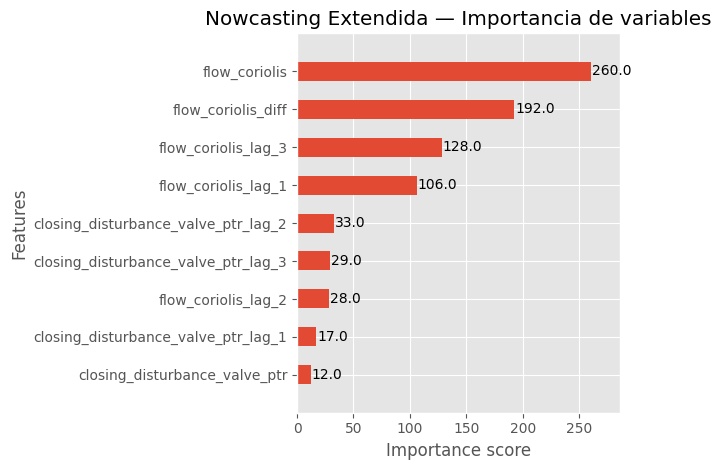

In [149]:
xgb.plot_importance(res_now_ext['modelo'], height=0.5, importance_type='weight', max_num_features=10)
plt.title('Nowcasting Extendida — Importancia de variables')
plt.tight_layout()
plt.show()